#Import required packages to be used in downstream process

# Data Cleaning and Pre-processing

## Data Integration

Multiple ERA5 variables were loaded and converted into pandas DataFrames. The variables included:

- Surface Pressure (sp)
- Skin Reservoir Content (src)
- Snow Cover (snowc)
- Snow Density (rsn)
- Snow Depth (sde)
- Leaf Area Index (High Vegetation)
- Leaf Area Index (Low Vegetation)
- Lake Bottom Temperature (lblt)
- Lake Ice Depth (licd)
- Lake Ice Temperature (lict)

The individual datasets were merged using an outer join on their common spatial and temporal indices to create a unified environmental dataset.

## Missing Value Treatment

Missing values were identified and quantified for each variable.

To preserve the dataset while maintaining statistical consistency, missing numerical values were replaced using mean imputation.

This approach:

- Prevented loss of observations.
- Maintained temporal continuity.
- Allowed machine learning algorithms to train without interruptions caused by null values.

## Geospatial Enrichment

Latitude and longitude coordinates were converted into geographic locations using reverse geocoding.

Location names were derived and grouped to facilitate location-specific forecasting and analysis.

This enabled regional exploration of environmental patterns and atmospheric variability.

In [2]:
!pip install reverse_geocoder
import reverse_geocoder as rg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for reverse_geocoder: filename=reverse_geocoder-1.5.1-py3-none-any.whl size=2268112 sha256=c001ad760f29a7bcfcd93f78fbdf20967e3bf5ecf86a63959f2ca2c517f9048e
  Stored in directory: /root/.cache/pip/wheels/61/62/ae/e0593fd403b7274fafb7a534ed54f9f880d0b5840963d64704
Successfully built reverse_geocoder


In [3]:
import xarray as xr

In [4]:
import pandas as pd

In [5]:
import seaborn as sns

#Load individual datasets for sea level temperatures, reservoir content, land cover, snow measures, surface pressure

In [6]:
la_ds = xr.open_dataset('/content/sample_data/leaf_area_index_high_vegetation_0_daily-mean.nc')
ladf =  la_ds.to_dataframe()
ladf_20k = ladf[300000:400000]
ladf_20k.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   lai_hv  23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [7]:
lkt_ds = xr.open_dataset('/content/sample_data/lake_bottom_temperature_0_daily-mean.nc')
lkt_df = lkt_ds.to_dataframe()
lkt_df_20k = lkt_df[300000:400000]
lkt_df_20k.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   lblt    23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [8]:
lid_ds = xr.open_dataset('/content/sample_data/lake_ice_depth_0_daily-mean.nc')
lid_df = lid_ds.to_dataframe()
lid_df_20k = lid_df[300000:400000]
lid_df_20k.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   licd    23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [9]:
lit_ds = xr.open_dataset('/content/sample_data/lake_ice_temperature_0_daily-mean.nc')
lit_df = lit_ds.to_dataframe()
lit_df_20k = lit_df[300000:400000]
lit_df_20k.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   lict    23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [10]:
lhv_ds = xr.open_dataset('/content/sample_data/leaf_area_index_high_vegetation_0_daily-mean.nc')
lhv_df = lhv_ds.to_dataframe()
lhv_df_20k = lhv_df[300000:400000]
lhv_df_20k.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   lai_hv  23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [12]:
llv_ds = xr.open_dataset('/content/sample_data/leaf_area_index_low_vegetation_0_daily-mean.nc')
llv_df = llv_ds.to_dataframe()
llv_df_20k = llv_df[300000:400000]
llv_df_20k.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   lai_lv  23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [13]:
src_ds = xr.open_dataset('/content/sample_data/skin_reservoir_content_0_daily-mean.nc')
src_df = src_ds.to_dataframe()
src_df_20k = src_df[300000:400000]
src_df_20k.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   src     23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [14]:
sc_ds = xr.open_dataset('/content/sample_data/snow_cover_0_daily-mean.nc')
sc_df = sc_ds.to_dataframe()
sc_df_20k = sc_df[300000:400000]
sc_df_20k.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   snowc   23723 non-null  float32
dtypes: float32(1)
memory usage: 1.1 MB


In [15]:
sd_ds = xr.open_dataset('/content/sample_data/snow_density_0_daily-mean.nc')
sd_df = sd_ds.to_dataframe()
sd_df_20k = sd_df[300000:400000]
sd_df_20k.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   rsn     23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


In [16]:
sdep_ds = xr.open_dataset('/content/sample_data/snow_depth_0_daily-mean.nc')
sdep_df = sdep_ds.to_dataframe()
sdep_df_20k = sdep_df[300000:400000]
sdep_df_20k.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sde     23723 non-null  float32
dtypes: float32(1)
memory usage: 1.1 MB


In [17]:
sp_ds = xr.open_dataset('/content/sample_data/surface_pressure_0_daily-mean.nc')
sp_df = sp_ds.to_dataframe()
sp_df_20k = sp_df[300000:400000]
sp_df_20k.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(119.99999999999746)) to (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(39.9000000000003))
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   sp      23723 non-null   float32
 1   number  100000 non-null  int64  
dtypes: float32(1), int64(1)
memory usage: 1.9 MB


#Merge all dataframes into a single dataframe using Merge Outer

In [18]:
merged_df = lkt_df_20k.drop(columns=['number'], errors='ignore') # Start with lkt_df, drop 'number' if it exists

for df_to_merge in [lid_df_20k, lit_df_20k, lhv_df_20k,
                    llv_df_20k, src_df_20k, sc_df_20k,
                    sd_df_20k, sdep_df_20k, sp_df_20k]:


    temp_df = df_to_merge.drop(columns=['number'], errors='ignore')

    merged_df = pd.merge(merged_df, temp_df, left_index=True, right_index=True, how='outer')

mdf = merged_df

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(0.0)) to (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(359.9))
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lblt    23723 non-null  float32
 1   licd    23723 non-null  float32
 2   lict    23723 non-null  float32
 3   lai_hv  23723 non-null  float32
 4   lai_lv  23723 non-null  float32
 5   src     23723 non-null  float32
 6   snowc   23723 non-null  float32
 7   rsn     23723 non-null  float32
 8   sde     23723 non-null  float32
 9   sp      23723 non-null  float32
dtypes: float32(10)
memory usage: 6.5 MB


#Merged data data-cleaning

#Check for null data sum and fill it with mean or string value

In [19]:
mdf.info()
mdf.isna().sum()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (Timestamp('2026-09-09 00:00:00'), np.float64(78.90000000000063), np.float64(0.0)) to (Timestamp('2026-09-09 00:00:00'), np.float64(81.70000000000047), np.float64(359.9))
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lblt    23723 non-null  float32
 1   licd    23723 non-null  float32
 2   lict    23723 non-null  float32
 3   lai_hv  23723 non-null  float32
 4   lai_lv  23723 non-null  float32
 5   src     23723 non-null  float32
 6   snowc   23723 non-null  float32
 7   rsn     23723 non-null  float32
 8   sde     23723 non-null  float32
 9   sp      23723 non-null  float32
dtypes: float32(10)
memory usage: 6.5 MB


,0
lblt,76277
licd,76277
lict,76277
lai_hv,76277
lai_lv,76277
src,76277
snowc,76277
rsn,76277
sde,76277
sp,76277


In [20]:
mdf['lai_lv'] = mdf['lai_lv'].fillna(mdf['lai_lv'].mean())
mdf['lai_hv'] = mdf['lai_hv'].fillna(mdf['lai_hv'].mean())
mdf['snowc'] = mdf['snowc'].fillna(mdf['snowc'].mean())
mdf['sde'] = mdf['sde'].fillna(mdf['sde'].mean())
mdf['rsn'] = mdf['rsn'].fillna(mdf['rsn'].mean())
mdf['lblt'] = mdf['lblt'].fillna(mdf['lblt'].mean())
mdf['sp'] = mdf['sp'].fillna(mdf['sp'].mean())
mdf['licd'] = mdf['licd'].fillna(mdf['licd'].mean())
mdf['lict'] = mdf['lict'].fillna(mdf['lict'].mean())
mdf['src'] = mdf['src'].fillna(mdf['src'].mean())

mdf.isna().sum()

,0
lblt,0
licd,0
lict,0
lai_hv,0
lai_lv,0
src,0
snowc,0
rsn,0
sde,0
sp,0


#Data Preparation
No. of locations

#Deriving location names from latitude and longitude

In [21]:
coords = list(zip(mdf.index.get_level_values('latitude'), mdf.index.get_level_values('longitude')))
results = rg.search(coords)
print(results)
mdf['location'] = results
mdf['city_country'] = mdf['location'].apply(lambda x: f"{x['name']}, {x['cc']}")
print(mdf['city_country'])


Loading formatted geocoded file...
[{'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.9221', 'lon': '-8.7187', 'name': 'Olonkinbyen', 'admin1': 'Jan Mayen', 'admin2': 'Jan Mayen', 'cc': 'SJ'}, {'lat': '70.

#Grouping data by location

In [23]:
groups = mdf.groupby('city_country')
#print(groups.head())

In [24]:
unique_locations = sorted(mdf['city_country'].unique())
print(unique_locations)
print("Total locations:", len(unique_locations))


['Anadyr, RU', 'Avanuorri, NO', 'Beringovskiy, RU', 'Berlevag, NO', 'Cherskiy, RU', 'Chokurdakh, RU', 'Deputatsky, RU', 'Dikson, RU', 'Honningsvag, NO', 'Iskateley, RU', 'Khatanga, RU', 'Longyearbyen, SJ', 'Mehamn, NO', 'Mys-Kamennyy, RU', "Nar'yan-Mar, RU", 'Olonkinbyen, SJ', 'Ostrovnoy, RU', 'Pevek, RU', 'Saskylakh, RU', 'Talnakh, RU', 'Teriberka, RU', 'Tiksi, RU', 'Tsementnozavodskiy, RU', 'Ust-Kuyga, RU', 'Vorgashor, RU', 'Vuorea, NO']
Total locations: 26


#Separate dataframes and csv store. local

In [25]:
for place, group in mdf.groupby("city_country"):
    parts = place.split(", ")
    country = parts[-1]
    city = ", ".join(parts[:-1])

    # Create a valid DataFrame variable name
    df_name = f"{city}_{country}_df".lower().replace(" ", "_").replace("-", "_")

    globals()[df_name] = group.reset_index(drop=True)
    # print(df_name)
    # print('***************')
    # print(globals()[df_name])
    # print('------------------')

In [26]:
import zipfile
import os

with zipfile.ZipFile(
    "city_csvs.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files_ in os.walk("city_csvs"):
        for file in files_:
            zipf.write(
                os.path.join(root, file),
                arcname=file
            )

print("ZIP created.")

ZIP created.


In [27]:
from google.colab import files

files.download("city_csvs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Surface Pressure Forecasting

## Research Objective

The aim of this study is to develop machine learning models capable of forecasting future surface pressure values using historical atmospheric observations.

Surface pressure is a fundamental meteorological variable that influences:

- Wind formation
- Cloud development
- Precipitation processes
- Atmospheric circulation

Accurate prediction of pressure changes can provide valuable insights into future weather conditions.

#Importing necessary libs

In [28]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import GRU

#Train test data split and importing necessary libs

In [29]:


# --------------------------------------------------
# Load data
# --------------------------------------------------
# Replace with your target column
df = vuorea_no_df

target_col = "sp"

data = df[target_col].values.reshape(-1, 1)

# --------------------------------------------------
# Scale target
# --------------------------------------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# --------------------------------------------------
# Create sequences
# --------------------------------------------------
lookback = 30
FORECAST_HORIZON = 7 # Define FORECAST_HORIZON here for data preparation

X, y = [], []

# Adjust loop range and y data to capture FORECAST_HORIZON future steps
for i in range(len(scaled_data) - lookback - FORECAST_HORIZON + 1):
    X.append(scaled_data[i:i + lookback])
    y.append(scaled_data[i + lookback : i + lookback + FORECAST_HORIZON]) # Collect FORECAST_HORIZON steps

X = np.array(X) # (samples, lookback, 1)
y = np.array(y) # (samples, FORECAST_HORIZON, 1)

# Reshape y to (samples, FORECAST_HORIZON) for XGBoost
y = y.reshape(y.shape[0], y.shape[1])


print("X shape:", X.shape)
print("y shape:", y.shape)

# --------------------------------------------------
# Train-test split
# --------------------------------------------------
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

X shape: (1042, 30, 1)
y shape: (1042, 7)


# LSTM Model

## Long Short-Term Memory Network

A Long Short-Term Memory (LSTM) neural network was developed to forecast future surface pressure values.

LSTM networks are designed to capture long-term temporal dependencies in sequential data and are widely used in weather forecasting applications.

## Data Preparation

- Surface pressure was scaled using MinMaxScaler.
- Historical observations were transformed into fixed-length sequences.
- A lookback window of 30 observations was used.
- The target consisted of future pressure values over a 7-day forecast horizon.

## Model Architecture

The model contains:

- LSTM layer
- Dense hidden layer
- Output layer

The network was trained using the Adam optimizer and Mean Squared Error loss function.

## Evaluation

Model performance was assessed using:

- Root Mean Squared Error (RMSE)

Lower RMSE values indicate better forecasting accuracy.

## Forecasting

The trained model was used to generate forecasts for the next seven days of surface pressure observations.

This allows evaluation of the model's ability to capture future atmospheric behaviour.

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0129 - val_loss: 5.8197e-04
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0124 - val_loss: 1.0988e-04
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0116 - val_loss: 4.0342e-04
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0112 - val_loss: 9.9417e-08
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0106 - val_loss: 1.5532e-05
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0104 - val_loss: 4.3713e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0101 - val_loss: 1.8565e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0099 - val_loss: 4.6412e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0100 - val_loss: 1.6431e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0101 - val_loss: 5.7003e-05
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0099 - val_loss: 8.9816e-05
Epoch 12/20
27/27 ━━━━━━━━━━━━

/tmp/ipykernel_584/2104016068.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


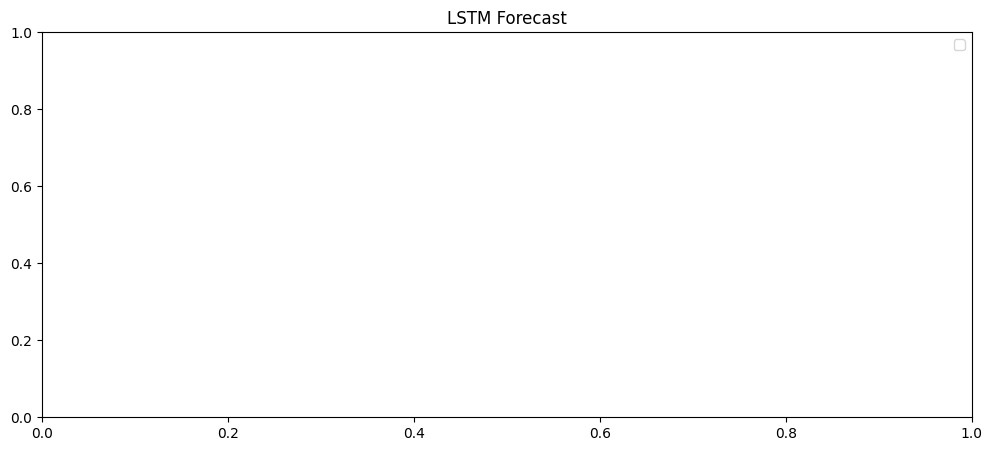

In [30]:
# --------------------------------------------------
# LSTM Model
# --------------------------------------------------
model = Sequential([
    LSTM(64, activation='tanh',
         input_shape=(lookback, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# --------------------------------------------------
# Predict on test set
# --------------------------------------------------
pred_scaled = model.predict(X_test)

pred_actual = scaler.inverse_transform(pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# RMSE
rmse = np.sqrt(np.mean((pred_actual - y_actual)**2))
print("RMSE:", rmse)

# --------------------------------------------------
# Forecast next 7 days
# --------------------------------------------------
last_sequence = scaled_data[-lookback:].copy()

future_scaled = []

for _ in range(7):

    pred = model.predict(
        last_sequence.reshape(1, lookback, 1),
        verbose=0
    )

    future_scaled.append(pred[0, 0])

    last_sequence = np.vstack([
        last_sequence[1:],
        pred
    ])

future_scaled = np.array(
    future_scaled
).reshape(-1, 1)

future_actual = scaler.inverse_transform(
    future_scaled
)

print("\nNext 7 Days Forecast:")
for i, value in enumerate(future_actual.flatten(), 1):
    print(f"Day {i}: {value:.2f}")

plt.figure(figsize=(12,5))

# plt.plot(
#     actual_inv[:,0],
#     label="Actual Day+1"
# )

# plt.plot(
#     pred_inv[:,0],
#     label="Predicted Day+1"
# )

plt.legend()

plt.title("LSTM Forecast")
plt.show()

# GRU Model

## Gated Recurrent Unit Network

A Gated Recurrent Unit (GRU) network was developed as an alternative recurrent neural network architecture.

GRU models use a simplified gating mechanism compared with LSTM networks and often achieve similar performance with lower computational complexity.

## Data Preparation

The same scaled surface pressure sequences used by the LSTM model were used for GRU training.

A lookback window of 30 observations was utilised to capture historical atmospheric patterns.

## Model Architecture

The network consists of:

- GRU layer
- Dense hidden layer
- Output layer

## Model Evaluation

Forecast accuracy was assessed using RMSE.

The GRU model was compared against both LSTM and XGBoost approaches to determine the effectiveness of recurrent neural networks for pressure forecasting.

## Forecasting

The trained GRU model generated a seven-day forecast of future surface pressure values.

Results were analysed to investigate the model's ability to learn temporal dependencies within atmospheric observations.

###GRU

In [31]:


model = Sequential([
    GRU(124, activation='relu',
         input_shape=(lookback, 1)),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# --------------------------------------------------
# Predict on test set
# --------------------------------------------------
pred_scaled = model.predict(X_test)

pred_actual = scaler.inverse_transform(pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# RMSE
rmse = np.sqrt(np.mean((pred_actual - y_actual)**2))
print("RMSE:", rmse)

# --------------------------------------------------
# Forecast next 7 days
# --------------------------------------------------
last_sequence = scaled_data[-lookback:].copy()

future_scaled = []

for _ in range(7):

    pred = model.predict(
        last_sequence.reshape(1, lookback, 1),
        verbose=0
    )

    future_scaled.append(pred[0, 0])

    last_sequence = np.vstack([
        last_sequence[1:],
        pred
    ])

future_scaled = np.array(
    future_scaled
).reshape(-1, 1)

future_actual = scaler.inverse_transform(
    future_scaled
)

print("\nNext 7 Days Forecast:")
for i, value in enumerate(future_actual.flatten(), 1):
    print(f"Day {i}: {value:.2f}")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0126 - val_loss: 6.6627e-05
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0112 - val_loss: 1.8224e-04
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0111 - val_loss: 5.0897e-05
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0108 - val_loss: 8.7736e-05
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0107 - val_loss: 3.6166e-05
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0106 - val_loss: 3.8679e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0104 - val_loss: 5.5919e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0103 - val_loss: 2.6668e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0103 - val_loss: 1.9801e-08
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0100 - val_loss: 1.2531e-05
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0100 - val_loss: 1.6567e-04
Epoch 12/20
27/27 ━━━━━━━━━━━━

# XGBoost Forecasting Model

## Introduction

Extreme Gradient Boosting (XGBoost) was selected as a machine learning approach for forecasting future surface pressure values. XGBoost is an ensemble learning algorithm based on gradient-boosted decision trees and is widely recognised for its ability to model complex non-linear relationships within environmental and atmospheric datasets.

Unlike recurrent neural networks, XGBoost does not explicitly learn temporal dependencies. Instead, historical observations are transformed into predictor features, allowing the model to learn relationships between previous atmospheric conditions and future surface pressure values.

## Data Preparation

Surface pressure observations were first normalised using MinMaxScaler to improve model stability.

A sliding window approach was then used to convert the time series into supervised learning samples:

- Lookback Window: 30 days
- Forecast Horizon: 7 days

For each observation, the model used the previous 30 days of surface pressure measurements as input and predicted future pressure values over the next seven days.

## Model Development

Separate XGBoost models were trained for each forecast horizon day.

Model configuration:

- Number of Trees: 300
- Maximum Tree Depth: 5
- Learning Rate: 0.05
- Objective Function: Squared Error Loss

The ensemble learning approach enables the model to capture non-linear relationships and interactions

Training complete
Prediction shape: (209, 7)
MAE  : 74.1116
RMSE : 79.4032


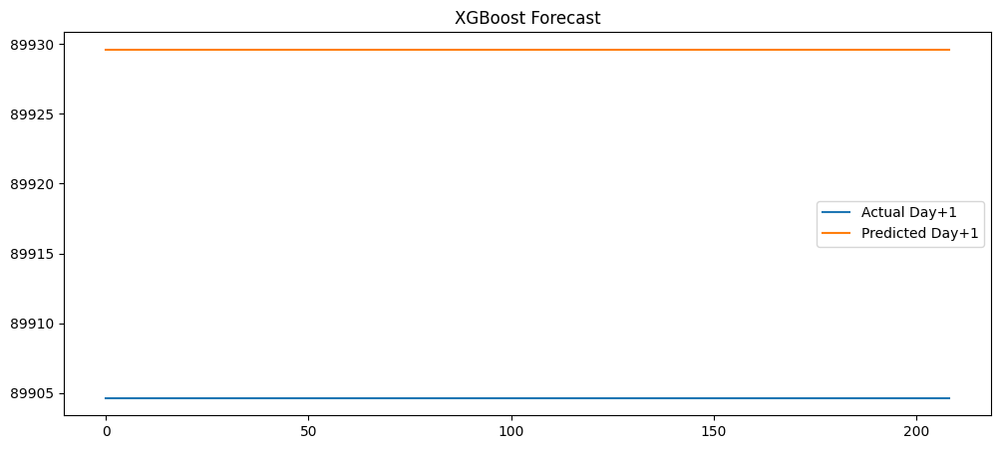


Predictions:
[[89929.6   89955.016 89967.74  89980.5   89993.305 90006.15  90019.01 ]
 [89929.6   89955.016 89967.74  89980.5   89993.305 90006.15  90019.01 ]
 [89929.6   89955.016 89967.74  89980.5   89993.305 90006.15  90019.01 ]
 [89929.6   89955.016 89967.74  89980.5   89993.305 90006.15  90019.01 ]
 [89929.6   89955.016 89967.74  89980.5   89993.305 90006.15  90019.01 ]]

Actual:
[[89904.65 89904.65 89904.65 89904.65 89904.65 89904.65 89904.65]
 [89904.65 89904.65 89904.65 89904.65 89904.65 89904.65 89904.65]
 [89904.65 89904.65 89904.65 89904.65 89904.65 89904.65 89904.65]
 [89904.65 89904.65 89904.65 89904.65 89904.65 89904.65 89904.65]
 [89904.65 89904.65 89904.65 89904.65 89904.65 89904.65 89904.65]]


In [ ]:


FORECAST_HORIZON = 7

# ========================================
# Train One XGBoost Per Forecast Day
# ========================================

models = []

for day in range(FORECAST_HORIZON):

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        objective="reg:squarederror",
        random_state=42
    )

    # Reshape X_train from (samples, lookback, 1) to (samples, lookback)
    X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1])

    model.fit(
        X_train_reshaped,
        y_train[:, day]
    )

    models.append(model)

print("Training complete")

# ========================================
# Predict
# ========================================

predictions = []

# Reshape X_test similarly for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1])

for day in range(FORECAST_HORIZON):

    pred = models[day].predict(X_test_reshaped)

    predictions.append(pred)

predictions = np.array(predictions).T

print("Prediction shape:", predictions.shape)

# ========================================
# Inverse Transform
# ========================================

pred_inv = scaler.inverse_transform(
    predictions.reshape(-1, 1)
).reshape(predictions.shape)

actual_inv = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(y_test.shape)

# ========================================
# Metrics
# ========================================

mae = mean_absolute_error(
    actual_inv.flatten(),
    pred_inv.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actual_inv.flatten(),
        pred_inv.flatten()
    )
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# ========================================
# Plot First Forecast Day
# ========================================

plt.figure(figsize=(12,5))

plt.plot(
    actual_inv[:,0],
    label="Actual Day+1"
)

plt.plot(
    pred_inv[:,0],
    label="Predicted Day+1"
)

plt.legend()

plt.title("XGBoost Forecast")
plt.show()

# ========================================
# Inspect Predictions
# ========================================

print("\nPredictions:")
print(pred_inv[:5])

print("\nActual:")
print(actual_inv[:5])

# Conclusion

This study explored the use of ERA5 environmental variables for surface pressure forecasting.

Data cleaning and preprocessing techniques were applied to create a unified environmental dataset. Spatial enrichment enabled location-based analysis, while exploratory visualisations provided insight into atmospheric relationships.

Three forecasting models including XGBoost, LSTM, and GRU were developed and evaluated. Model performance was measured using RMSE and MAE to determine the most effective approach for surface pressure prediction.

Future work could incorporate:

- Additional ERA5 variables
- Spatial forecasting methods
- Extreme weather event prediction
- Explainable AI techniques such as SHAP
- Multi-variable Earth system prediction

These extensions would further strengthen the application of machine learning methods to atmospheric and environmental forecasting.